# Agent 结构化输出

`create_agent` 通过 `response_format` 让 Agent 在完成对话后返回**结构化数据**，而不是一段自然语言。结果会放在最终 state 的 `structured_response` 键里。

## 四种策略总览

| 策略 | 传法 | 说明 |
| --- | --- | --- |
| 直接传 schema | `response_format=Schema` | 由框架根据模型能力自动选择策略（内部包装为 `AutoStrategy`）|
| `AutoStrategy` | `AutoStrategy(Schema)` | 显式要求自动选择：支持原生输出的模型用 Provider，否则用 Tool |
| `ToolStrategy` | `ToolStrategy(Schema)` | 用「工具调用」产出结构化输出，适用范围最广 |
| `ProviderStrategy` | `ProviderStrategy(Schema)` | 用服务商原生的结构化输出（OpenAI/Anthropic/xAI/Gemini 等）|

> 另外 `response_format=None` 表示不请求结构化输出。

In [1]:
import os

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.agents.structured_output import (
    AutoStrategy,
    ProviderStrategy,
    ToolStrategy,
)
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field

load_dotenv(override=True)

# 关闭 DeepSeek 的思考模式：
# 否则结构化输出（内部强制 tool_choice）会报 “Thinking mode does not support this tool_choice”
model = init_chat_model(
    api_base=os.getenv("DEEPSEEK_API_BASE"),
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    model="deepseek-flash",
    model_provider="deepseek",
    model_kwargs={"reasoning_effort": "none"},
)


class ContactInfo(BaseModel):
    """联系人信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="邮箱")


MESSAGES = [{"role": "user", "content": "提取联系人信息：张三，zhang@example.com"}]


/Users/lijixu/PycharmProjects/langchain_demo/.venv/lib/python3.14/site-packages/langchain_core/utils/pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1
/Users/lijixu/PycharmProjects/langchain_demo/.venv/lib/python3.14/site-packages/langchain/chat_models/base.py:516: UserWarning: Parameters {'reasoning_effort'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  return _init_chat_model_helper(


## 策略 1：直接传 schema（自动选择）

In [2]:
# 直接传 Pydantic 模型 / TypedDict / dataclass / JSON Schema
# LangChain 会读取模型的 profile 自动选择 ProviderStrategy 或 ToolStrategy
agent_raw = create_agent(model=model, response_format=ContactInfo)

result = agent_raw.invoke({"messages": MESSAGES})
print(result["structured_response"])


name='张三' email='zhang@example.com'


## 策略 2：AutoStrategy（显式自动）

In [3]:
# 与策略 1 等价，但显式声明「自动选择」的意图
# 支持原生结构化输出的模型走 ProviderStrategy，否则回退到 ToolStrategy
agent_auto = create_agent(model=model, response_format=AutoStrategy(ContactInfo))

result = agent_auto.invoke({"messages": MESSAGES})
print(result["structured_response"])


name='张三' email='zhang@example.com'


## 策略 3：ToolStrategy（工具调用）

In [4]:
# 通过一个「结构化输出工具」，让模型以工具调用的形式给出结构化结果
agent_tool = create_agent(model=model, response_format=ToolStrategy(ContactInfo))

result = agent_tool.invoke({"messages": MESSAGES})
print(result["structured_response"])


name='张三' email='zhang@example.com'


In [5]:
# ToolStrategy 还支持自定义工具消息与错误重试策略
agent_tool2 = create_agent(
    model=model,
    response_format=ToolStrategy(
        schema=ContactInfo,
        tool_message_content="已捕获结构化结果",   # 命中结构化输出后返回的 ToolMessage 内容
        handle_errors=True,                        # 校验失败时自动把错误反馈给模型并重试
    ),
)

result = agent_tool2.invoke({"messages": MESSAGES})
print(result["structured_response"])


name='张三' email='zhang@example.com'


## 策略 4：ProviderStrategy（厂商原生）

In [6]:
# ProviderStrategy 使用服务商原生的结构化输出（如 OpenAI 的 response_format=json_schema）
# 注意：DeepSeek 目前不支持，会报 “This response_format type is unavailable now”
# 仅当模型/服务商支持原生结构化输出时才可用（OpenAI / Anthropic / xAI / Gemini 等）
try:
    agent_provider = create_agent(
        model=model,
        response_format=ProviderStrategy(ContactInfo),
    )
    result = agent_provider.invoke({"messages": MESSAGES})
    print(result["structured_response"])
except Exception as e:
    print("当前模型不支持 ProviderStrategy：", type(e).__name__)
    print(str(e)[:150])


当前模型不支持 ProviderStrategy： OpenAIInvalidRequestError
Error code: 400 - {'error': {'message': 'This response_format type is unavailable now', 'type': 'invalid_request_error', 'param': None, 'code': 'inval


## 综合示例：先调用工具，再结构化输出

In [7]:
from langchain_core.tools import tool

from charpter02.utils import get_weather


class WeatherReport(BaseModel):
    """天气报告"""
    city: str = Field(description="城市")
    temperature: float = Field(description="摄氏温度")
    summary: str = Field(description="一句话总结")


@tool
def get_weather_tool(city: str) -> str:
    """查询给定城市的天气

    :param city: 城市名称，如北京、上海
    """
    return get_weather(city)


# Agent 会先调用工具获取信息，最后再产出结构化的 WeatherReport
agent_weather = create_agent(
    model=model,
    tools=[get_weather_tool],
    system_prompt="你是天气助手",
    response_format=WeatherReport,   # 这里用的是「策略 1：直接传 schema」
)

result = agent_weather.invoke(
    {"messages": [{"role": "user", "content": "上海今天的天气怎么样？"}]}
)
print("structured_response:", result["structured_response"])
# 执行轨迹：HumanMessage -> AI(调用工具) -> ToolMessage -> AI -> ToolMessage(结构化结果)
print("执行轨迹：", [type(m).__name__ for m in result["messages"]])


structured_response: city='上海' temperature=26.0 summary='上海今天气温26°C，湿度65%，风速9.9公里/小时，天气较为舒适。'
执行轨迹： ['HumanMessage', 'AIMessage', 'ToolMessage', 'AIMessage', 'ToolMessage']


## 补充：使用 `@dataclass` 作为 schema

In [ ]:
# 除 Pydantic 外，response_format 也支持 @dataclass、TypedDict、JSON Schema
# dataclass 没有 Field()，字段描述用 Annotated 附加
from dataclasses import dataclass, is_dataclass
from typing import Annotated


@dataclass
class ContactInfoDC:
    """联系人信息"""
    name: Annotated[str, "姓名"]
    email: Annotated[str, "邮箱"]


# 用法与 Pydantic 完全一致：可直接传，也可放进 AutoStrategy / ToolStrategy
agent_dc = create_agent(model=model, response_format=ContactInfoDC)

result = agent_dc.invoke({"messages": MESSAGES})
structured = result["structured_response"]

print(structured)                                  # ContactInfoDC(name='张三', email='zhang@example.com')
print("是否 dataclass 实例：", is_dataclass(structured))
print("按属性取值：", structured.name, structured.email)


> 小结：`@dataclass` 可以作为 `response_format` 的 schema，与 Pydantic 一样支持直接传、`AutoStrategy`、`ToolStrategy`；本版本返回的是 **dataclass 实例**（可直接用 `.name` 访问），`ProviderStrategy` 在 DeepSeek 上仍不可用。

### 运行时校验

Agent 内部对 `Pydantic` / `dataclass` / `TypedDict` 都会用 Pydantic 的 `TypeAdapter` 做**运行时校验**（类型 + `Annotated[..., Field(...)]` 约束）；只有「原始 JSON Schema `dict`」不校验，直接原样返回。

`ToolStrategy` 校验失败时会抛出 `StructuredOutputValidationError`：默认 `handle_errors=True` 会把错误作为 `ToolMessage` 回传给模型自动重试；设为 `False` 则直接抛出异常。

In [ ]:
# 运行时校验演示：dataclass 的字段会被 TypeAdapter 校验（与 Agent 内部一致）
from pydantic import Field, TypeAdapter, ValidationError

@dataclass
class Rating:
    """评分"""
    score: Annotated[int, Field(ge=1, le=5)]   # 约束：1~5
    comment: str


ta = TypeAdapter(Rating)
print("合法：", ta.validate_python({"score": 5, "comment": "不错"}))

try:
    ta.validate_python({"score": 10, "comment": "越界"})   # 超出约束
except ValidationError as e:
    print("越界：校验失败 ->", str(e).splitlines()[-1])


## `handle_errors` 设置案例

`ToolStrategy` 通过 `handle_errors` 控制校验失败后的重试行为：

| 取值 | 行为 |
| --- | --- |
| `True`（默认） | 捕获所有错误，用默认模板消息反馈给模型并重试 |
| `False` | 不重试，直接抛出 `StructuredOutputValidationError` |
| `str` | 用固定字符串作为错误消息并重试 |
| `type[Exception]` | 仅当异常是该类型时才重试，否则抛出 |
| `tuple[type[Exception], ...]` | 命中其中任一异常类型时重试，否则抛出 |
| `Callable[[Exception], str]` | 用自定义函数返回错误消息并重试 |

In [9]:
from langchain.agents.structured_output import StructuredOutputValidationError
from pydantic import BaseModel, Field


class Review(BaseModel):
    """评价"""
    comment: str = Field(description="评价内容，至少 20 个字", min_length=20)


# 故意让模型第一次只写一句很短的话，从而触发长度校验失败
BRIEF_SYSTEM = "你只会回复一句极简的夸赞，永远不要超过 6 个字。"
USER = {"role": "user", "content": "夸我一句"}


In [12]:
# 取值 False：不重试，直接把校验异常抛出来
agent = create_agent(
    model=model,
    response_format=ToolStrategy(Review, handle_errors=False),
    system_prompt=BRIEF_SYSTEM,
)

try:
    agent.invoke({"messages": [USER]})
except StructuredOutputValidationError as e:
    print("已按预期抛出：", type(e).__name__)
    print(str(e))


已按预期抛出： StructuredOutputValidationError
Failed to parse structured output for tool 'Review': Failed to parse data to Review: 1 validation error for Review
comment
  String should have at least 20 characters [type=string_too_short, input_value='你真是特别棒，太优秀了！', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/string_too_short.


In [14]:
# 取值 True（默认）：把错误作为 ToolMessage 回传模型，自动重试直到通过
agent = create_agent(
    model=model,
    response_format=ToolStrategy(Review, handle_errors=True),
    system_prompt=BRIEF_SYSTEM,
)

result = agent.invoke({"messages": [USER]})
for m in result["messages"]:
    if type(m).__name__ == "ToolMessage":
        print("ToolMessage:", str(m.content))
print("最终结果：", result["structured_response"])


ToolMessage: Error: Failed to parse structured output for tool 'Review': Failed to parse data to Review: 1 validation error for Review
comment
  String should have at least 20 characters [type=string_too_short, input_value='用户主动求夸，我...诚的简短赞美。', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/string_too_short.
 Please fix your mistakes.
ToolMessage: Returning structured response: comment='用户主动求夸，我用极简的六个字以内赞美回应用户，表达真诚善意。'
最终结果： comment='用户主动求夸，我用极简的六个字以内赞美回应用户，表达真诚善意。'


In [15]:
# 取值 str：重试时用这句固定消息替换默认错误模板
agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Review,
        handle_errors="评价太短了，请扩充到至少 20 个字再返回。",
    ),
    system_prompt=BRIEF_SYSTEM,
)

result = agent.invoke({"messages": [USER]})
print("重试消息：", [str(m.content) for m in result["messages"] if type(m).__name__ == "ToolMessage"])
print("最终结果：", result["structured_response"])


重试消息： ['评价太短了，请扩充到至少 20 个字再返回。', '评价太短了，请扩充到至少 20 个字再返回。', "Returning structured response: comment='你真的很棒，光芒万丈，独一无二，令人由衷喜欢。'"]
最终结果： comment='你真的很棒，光芒万丈，独一无二，令人由衷喜欢。'


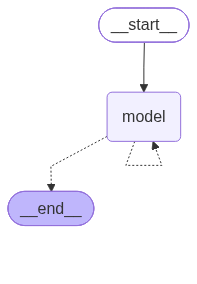

重试消息： ['格式或长度不对，请按要求修正后重新返回。', "Returning structured response: comment='你真的非常出色，令人由衷赞叹，真的很厉害。'"]
最终结果： comment='你真的非常出色，令人由衷赞叹，真的很厉害。'


In [18]:
# 取值 Callable：根据异常类型返回不同的错误提示
from IPython.display import Image, display
from langchain.agents.structured_output import MultipleStructuredOutputsError
from langgraph.errors import GraphRecursionError


def my_handler(error: Exception) -> str:
    if isinstance(error, StructuredOutputValidationError):
        return "格式或长度不对，请按要求修正后重新返回。"
    if isinstance(error, MultipleStructuredOutputsError):
        return "一次只能返回一个结构化结果。"
    return f"出错了：{error}"


agent = create_agent(
    model=model,
    response_format=ToolStrategy(Review, handle_errors=my_handler),
    system_prompt=BRIEF_SYSTEM,
)

# 打印 Agent 的图：model 节点上的自环表示模型会被反复调用，直到产出合规结果
display(Image(agent.get_graph().draw_mermaid_png()))

# 最大调用次数限制：通过 invoke 的 config["recursion_limit"] 限制图的执行步数（默认 25）
# 本例的系统提示与 schema 约束相互冲突，重试会一直循环，超过限制时抛出 GraphRecursionError
try:
    result = agent.invoke(
        {"messages": [USER]},
        config={"recursion_limit": 25},   # 最多执行 6 个 super-step
    )
    print("重试消息：", [str(m.content) for m in result["messages"] if type(m).__name__ == "ToolMessage"])
    print("最终结果：", result["structured_response"])
except GraphRecursionError:
    print("已达到最大调用次数限制：GraphRecursionError")


In [ ]:
# 取值 type / tuple：只有「匹配」的异常类型才会重试，否则直接抛出
# 注意：校验错误实际抛出的是 StructuredOutputValidationError（它不是 ValueError 的子类），
# 所以写 ValueError 不会命中，会被直接抛出 —— 要写 StructuredOutputValidationError

for label, exc in [
    ("handle_errors=ValueError", ValueError),                       # 不命中 -> 抛出
    ("handle_errors=StructuredOutputValidationError", StructuredOutputValidationError),  # 命中 -> 重试
]:
    agent = create_agent(
        model=model,
        response_format=ToolStrategy(Review, handle_errors=exc),
        system_prompt=BRIEF_SYSTEM,
    )
    try:
        result = agent.invoke({"messages": [USER]})
        print(f"{label}: 重试成功 -> {result['structured_response']}")
    except Exception as e:
        print(f"{label}: 直接抛出 -> {type(e).__name__}")

# tuple：命中其中任意一个异常类型即重试
agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Review,
        handle_errors=(ValueError, StructuredOutputValidationError),
    ),
    system_prompt=BRIEF_SYSTEM,
)
result = agent.invoke({"messages": [USER]})
print("handle_errors=(ValueError, StructuredOutputValidationError): 重试成功 ->", result["structured_response"])


## 注意事项

1. **结果在 `structured_response`**：从最终 state 里取，不在 `messages` 的最后一条。
2. **DeepSeek 要先关闭思考模式**：传 `model_kwargs={"reasoning_effort": "none"}`，否则会触发 `Thinking mode does not support this tool_choice`。
3. **自动选择依赖模型 profile**：`langchain>=1.1` 会从模型的 `profile` 读取 `structured_output` 能力；DeepSeek 该能力为 `None`，因此自动回退到 `ToolStrategy`。
4. **ProviderStrategy 看服务商**：只有原生支持结构化输出的服务商（OpenAI、Anthropic、xAI、Gemini 等）可用，DeepSeek 会报 `This response_format type is unavailable now`。
5. **JSON Schema `dict` 必须显式包装**：传 `ToolStrategy(schema)` 或 `ProviderStrategy(schema)`，不会像类型注解那样被自动识别。
6. **`ToolStrategy` 支持 `Union`**：传入多个 schema 时由模型选择最合适的一个；可用 `handle_errors` 控制校验失败后的重试行为。